<a href="https://colab.research.google.com/github/claraaqn/mineracao-texto/blob/main/atividade%2002/03_Classifica%C3%A7%C3%A3o_Textos_BoW_TF_IDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizado Bayesiano: Naive Bayes

O algoritmo Naive Bayes, assim como o KNN é um algoritmo de aprendizado com implementação relativamente simples, e que pode levar a resultados muito bons em determinados problemas de classificação. Este consiste em aplicar o teorema de Bayes, com a prerrogativa de independencia condicional entre cada par de atributos dado o valor da classe.

Clique nos links para mais informações sobre o algoritmo [Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html#naive-bayes) e sobre [classificação de textos](https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html). com scikit-learn.

# Exemplo: classificação de texto

Neste exemplo, utilizaremos um dataset chamado 20newsgroups.

O conjunto de dados é uma coleção de aproximadamente 20.000 documentos de grupos de notícias, particionados (quase) uniformemente em 20 grupos/categorias de notícias diferentes. Mais informações sobre esta base podem ser obtidas no repositório [UCI](http://archive.ics.uci.edu/ml/datasets/Twenty+Newsgroups)

As categorias existentes são:

* 'alt.atheism',
* 'comp.graphics',
* 'comp.os.ms-windows.misc',
* 'comp.sys.ibm.pc.hardware',
* 'comp.sys.mac.hardware',
* 'comp.windows.x',
* 'misc.forsale',
* 'rec.autos',
* 'rec.motorcycles',
* 'rec.sport.baseball',
* 'rec.sport.hockey',
* 'sci.crypt',
* 'sci.electronics',
* 'sci.med',
* 'sci.space',
* 'soc.religion.christian',
* 'talk.politics.guns',
* 'talk.politics.mideast',
* 'talk.politics.misc',
* 'talk.religion.misc'

Neste exemplo, vamos considerar apenas duas categorias: '**alt.atheism**' e '**comp.graphics**'. O scitkit contém uma função que auxilia o download desta base:

In [1]:
from sklearn.datasets import fetch_20newsgroups

# Categorias selecionadas
categories = [
    'alt.atheism',
    'comp.graphics',
]

print("Carregando 20 newsgroups dataset para as categorias:")
print(categories)

twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)
twenty_test  = fetch_20newsgroups(subset='test',  categories=categories, shuffle=True, random_state=42)
print("%d documents" % len(twenty_train.filenames))
print("%d categories" % len(twenty_train.target_names))

Carregando 20 newsgroups dataset para as categorias:
['alt.atheism', 'comp.graphics']
1064 documents
2 categories


In [2]:
# Visualizar os dados coletados
print(twenty_train.keys())

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])


In [3]:
# Visualizando um dos documentos
print(twenty_train['data'][0])

From: frank@D012S658.uucp (Frank O'Dwyer)
Subject: Re: After 2000 years, can we say that Christian Morality is
Organization: Siemens-Nixdorf AG
Lines: 28
NNTP-Posting-Host: d012s658.ap.mchp.sni.de

In article <1993Apr15.125245.12872@abo.fi> MANDTBACKA@FINABO.ABO.FI (Mats Andtbacka) writes:
|In <1qie61$fkt@horus.ap.mchp.sni.de> frank@D012S658.uucp writes:
|> In article <30114@ursa.bear.com> halat@pooh.bears (Jim Halat) writes:
|
|> #I'm one of those people who does not know what the word objective means 
|> #when put next to the word morality.  I assume its an idiom and cannot
|> #be defined by its separate terms.
|> #
|> #Give it a try.
|> 
|> Objective morality is morality built from objective values.
|
|      "And these objective values are ... ?"
|Please be specific, and more importantly, motivate.

I'll take a wild guess and say Freedom is objectively valuable.  I base
this on the assumption that if everyone in the world were deprived utterly
of their freedom (so that their every a

In [4]:
# tamanho (sem preprocessamento)
len(twenty_train['data'][0])

1577

## Preprocessamento

Como etapa de préprocessamento, iremos apenas nos limitar a remover palavras muito comuns, as chamadas *stopwords*. Uma lista de possíveis stopwords para inglês encontra-se abaixo:

In [5]:
stopwords = ['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', "aren't", 'as', 'at',
             'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by',  'can', "can't", 'cannot', 'could', "couldn't",
             'did', "didn't", 'do', 'does', "doesn't", 'doing', "don't", 'down', 'during','each', 'few', 'for', 'from', 'further',
             'had', "hadn't", 'has', "hasn't", 'have', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'her', 'here', "here's",
             'hers', 'herself', 'him', 'himself', 'his', 'how', "how's",'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', "isn't",
             'it', "it's", 'its', 'itself','1st', '2nd', '3rd','4th', '5th', '6th', '7th', '8th', '9th', '10th'
             "let's", 'me', 'more', 'most', "mustn't", 'my', 'myself','no', 'nor', 'not', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'ought', 'our', 'ours' 'ourselves', 'out', 'over', 'own',
             'same', "shan't", 'she', "she'd", "she'll", "she's", 'should', "shouldn't", 'so', 'some', 'such',
             'than', 'that',"that's", 'the', 'their', 'theirs', 'them', 'themselves', 'then', 'there', "there's", 'these', 'they', "they'd",
             "they'll", "they're", "they've", 'this', 'those', 'through', 'to', 'too', 'under', 'until', 'up', 'very',
             'was', "wasn't", 'we', "we'd", "we'll", "we're", "we've", 'were', "weren't", 'what', "what's", 'when', "when's", 'where',
             "where's", 'which', 'while', 'who', "who's", 'whom', 'why', "why's",'will', 'with', "won't", 'would', "wouldn't",
             'you', "you'd", "you'll", "you're", "you've", 'your', 'yours', 'yourself', 'yourselves',
             'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten', 'hundred', 'thousand']

### Exercício

Complemente o código abaixo para:
* descartar stopwords
* descartar palavras com menos de 3 caracteres
* descartar tokens contendo apenas numeros

In [6]:
import string
from nltk.tokenize.regexp import RegexpTokenizer

def preprocess(text):

  # remover pontuações
  text   = text.translate(string.punctuation)

  # converter para lowercase
  text = text.lower()

  # tokenizar o texto em palavras
  tokenizer = RegexpTokenizer(r'\w+')
  tokens = tokenizer.tokenize(text.lower())

  # SEU CÓDIGO AQUI
  tokens = [t for t in tokens if t not in stopwords and len(t) >= 3 and not t.isdigit()]

  return ' '.join(tokens)

X_train = []
for doc in twenty_train['data']:
  X_train.append(preprocess(doc))

X_test = []
for doc in twenty_test['data']:
  X_test.append(preprocess(doc))

print(X_train[0])

frank d012s658 uucp frank dwyer subject years say christian morality organization siemens nixdorf lines nntp posting host d012s658 mchp sni article 1993apr15 abo mandtbacka finabo abo mats andtbacka writes 1qie61 fkt horus mchp sni frank d012s658 uucp writes article ursa bear com halat pooh bears jim halat writes people know word objective means put next word morality assume idiom defined separate terms give try objective morality morality built objective values objective values please specific importantly motivate take wild guess say freedom objectively valuable base assumption everyone world deprived utterly freedom every act contrary volition almost want complain therefore take assert believe freedom valuable almost everyone see every bit absurd assert raining rainy day take candidate objective value necessary condition objective morality objective values exist frank dwyer hatching odwyer sse hens evelyn conlon


In [7]:
# tamanho (com preprocessamento)
len(X_train[0])

927

## Representação vetorial do texto

Neste exemplo, utilizaremos o algoritmo Naive Bayes para classificar documentos de texto em categorias. Para isso, precisamos antes converter o texto para uma representação vetorial, ou seja, cada documento/exemplo precisa ser representado por um vetor de dimensões pré-definidas. Utilizaremos três técnicas básicas: BOW (*Bag of Words*), TF (*Term Frequency*) e TF-IDF (*Term Frequency - Inverse Document Frequency*)

### BOW

Consiste basicamente em contar quantas vezes cada palavra aparece no documento. Ou seja, sua aplicação a um conjunto de *n* documentos, produz uma matriz *n x d*, onde *d* corresponde ao tamanho do vocabulário considerado. No Scikit, esta representação é implementada pelo [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html#sklearn.feature_extraction.text.CountVectorizer):

In [8]:
# Exemplo de uso do BOW no scikit

from sklearn.feature_extraction.text import CountVectorizer
corpus = [
    'This is the first document.',
    'This document is the second document.',
    'And this is the third one.',
    'Is this the first document?',
]
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)
print(vectorizer.get_feature_names_out())
print(X.toarray())

['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']
[[0 1 1 1 0 0 1 0 1]
 [0 2 0 1 0 1 1 0 1]
 [1 0 0 1 1 0 1 1 1]
 [0 1 1 1 0 0 1 0 1]]


Aplicando ao nosso dataset:

In [9]:
vectorizer = CountVectorizer()
bow_model  = vectorizer.fit(X_train)

X_bow_train = bow_model.transform(X_train)
X_bow_test  = bow_model.transform(X_test)

print(X_bow_train.shape,X_bow_test.shape)

(1064, 19198) (708, 19198)


In [10]:
# matriz está armazenada em formato sparse
print(X_bow_train[0,:])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 95 stored elements and shape (1, 19198)>
  Coords	Values
  (0, 96)	1
  (0, 192)	1
  (0, 735)	2
  (0, 768)	1
  (0, 872)	1
  (0, 1218)	2
  (0, 1356)	1
  (0, 1657)	2
  (0, 1710)	2
  (0, 1733)	1
  (0, 1737)	1
  (0, 2056)	1
  (0, 2107)	1
  (0, 2110)	1
  (0, 2177)	1
  (0, 2356)	1
  (0, 2758)	1
  (0, 2980)	1
  (0, 3402)	1
  (0, 3717)	1
  (0, 3859)	1
  (0, 3972)	1
  (0, 4021)	1
  (0, 4157)	1
  (0, 4650)	3
  :	:
  (0, 15123)	2
  (0, 15330)	1
  (0, 15407)	1
  (0, 15634)	1
  (0, 15869)	2
  (0, 16063)	1
  (0, 16193)	1
  (0, 16485)	1
  (0, 16848)	3
  (0, 17043)	1
  (0, 17143)	1
  (0, 17598)	1
  (0, 18043)	1
  (0, 18112)	1
  (0, 18115)	2
  (0, 18164)	2
  (0, 18165)	1
  (0, 18167)	3
  (0, 18437)	1
  (0, 18539)	1
  (0, 18751)	1
  (0, 18870)	2
  (0, 18892)	1
  (0, 18938)	3
  (0, 19084)	1


### *Term Frequency* (TF)
A contagem de ocorrências (i.e., BOW) é um bom começo, mas há um problema: documentos mais longos terão valores de contagem média mais altos do que documentos mais curtos, embora possam falar sobre os mesmos tópicos.

Para evitar essas possíveis discrepâncias, basta dividir o número de ocorrências de cada palavra em um documento pelo número total de palavras no documento:

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(use_idf=False)
tf_model = vectorizer.fit(X_train)

X_tf_train = tf_model.transform(X_train)
X_tf_test  = tf_model.transform(X_test)

print(X_tf_train[0,:])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 95 stored elements and shape (1, 19198)>
  Coords	Values
  (0, 96)	0.06154574548966636
  (0, 192)	0.06154574548966636
  (0, 735)	0.12309149097933272
  (0, 768)	0.06154574548966636
  (0, 872)	0.06154574548966636
  (0, 1218)	0.12309149097933272
  (0, 1356)	0.06154574548966636
  (0, 1657)	0.12309149097933272
  (0, 1710)	0.12309149097933272
  (0, 1733)	0.06154574548966636
  (0, 1737)	0.06154574548966636
  (0, 2056)	0.06154574548966636
  (0, 2107)	0.06154574548966636
  (0, 2110)	0.06154574548966636
  (0, 2177)	0.06154574548966636
  (0, 2356)	0.06154574548966636
  (0, 2758)	0.06154574548966636
  (0, 2980)	0.06154574548966636
  (0, 3402)	0.06154574548966636
  (0, 3717)	0.06154574548966636
  (0, 3859)	0.06154574548966636
  (0, 3972)	0.06154574548966636
  (0, 4021)	0.06154574548966636
  (0, 4157)	0.06154574548966636
  (0, 4650)	0.1846372364689991
  :	:
  (0, 15123)	0.12309149097933272
  (0, 15330)	0.06154574548966636
  (0, 15407)	0.0

### TF-IDF
Usando o scikit, basta ativar o flag `use_idf=True`:

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(use_idf=True)
tfidf_model = vectorizer.fit(X_train)

X_tfidf_train = tfidf_model.transform(X_train)
X_tfidf_test  = tfidf_model.transform(X_test)

print(X_tfidf_train[0,:])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 95 stored elements and shape (1, 19198)>
  Coords	Values
  (0, 96)	0.0641047395707275
  (0, 192)	0.09569710295526648
  (0, 735)	0.15520809231080354
  (0, 768)	0.07328500957668772
  (0, 872)	0.061093742712638725
  (0, 1218)	0.11038390555364601
  (0, 1356)	0.07893128011279814
  (0, 1657)	0.05069206200584803
  (0, 1710)	0.17208947943952138
  (0, 1733)	0.05798637580507152
  (0, 1737)	0.06674001324874913
  (0, 2056)	0.06795168291989598
  (0, 2107)	0.07760404615540177
  (0, 2110)	0.07639237648425491
  (0, 2177)	0.04342919407834219
  (0, 2356)	0.04480001309971594
  (0, 2758)	0.06230541238378557
  (0, 2980)	0.08858364334830392
  (0, 3402)	0.04912996729292313
  (0, 3717)	0.02770205214115781
  (0, 3859)	0.08039846918365028
  (0, 3972)	0.07760404615540177
  (0, 4021)	0.09169101025587112
  (0, 4157)	0.07238628378485955
  (0, 4650)	0.20579848054974437
  :	:
  (0, 15123)	0.07177445261162288
  (0, 15330)	0.03735441537666359
  (0, 15407)	0.

# Treinando modelo NaiveBayes (NB)

In [13]:
from sklearn.naive_bayes import MultinomialNB

clf = MultinomialNB()

## BOW + NB

In [14]:
clf.fit(X_bow_train, twenty_train.target)

acc = clf.score(X_bow_test , twenty_test.target)
print('Acurácia: ', acc)

Acurácia:  0.980225988700565


## TF + NB

In [15]:
clf.fit(X_tf_train, twenty_train.target)

acc = clf.score(X_tf_test , twenty_test.target)
print('Acurácia: ', acc)

Acurácia:  0.9745762711864406


## TF-IDF + NB

In [16]:
clf.fit(X_tfidf_train, twenty_train.target)

acc = clf.score(X_tfidf_test , twenty_test.target)
print('Acurácia: ', acc)

Acurácia:  0.9759887005649718


## Exercício: explore outras métricas

Utilize a função `sklearn.metrics.ConfusionMatrixDisplay` para visualizar a matriz de confusão.

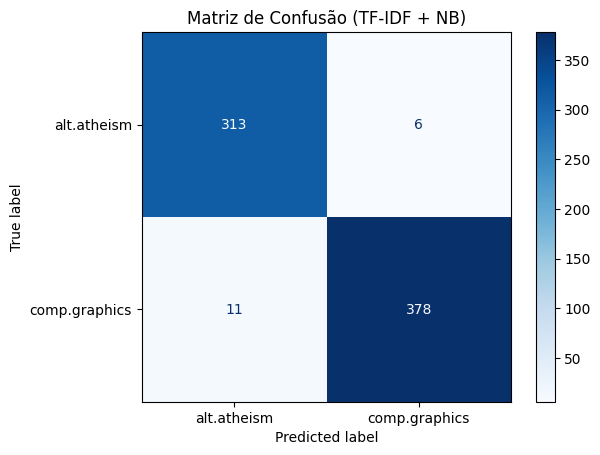

In [17]:
# SEU CÓDIGO AQUI
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = clf.predict(X_tfidf_test)

ConfusionMatrixDisplay.from_predictions(
    twenty_test.target,
    y_pred,
    display_labels=twenty_train.target_names,
    cmap='Blues'
)
plt.title("Matriz de Confusão (TF-IDF + NB)")
plt.show()

Utilize a função `sklearn.metrics.classification_report` para visualizar a as métricas de precision, recall e F1 score

In [18]:
# SEU CÓDIGO AQUI
from sklearn.metrics import classification_report

relatorio = classification_report(
    twenty_test.target,
    y_pred,
    target_names=twenty_train.target_names
)

print(relatorio)

               precision    recall  f1-score   support

  alt.atheism       0.97      0.98      0.97       319
comp.graphics       0.98      0.97      0.98       389

     accuracy                           0.98       708
    macro avg       0.98      0.98      0.98       708
 weighted avg       0.98      0.98      0.98       708



Crie um dataframe pandas, e visualize os casos em que os modelos erraram de cada classe

In [20]:
# SEU CÓDIGO AQUI
import pandas as pd

df_resultados = pd.DataFrame({
    'Texto Original': twenty_test['data'],
    'Texto Preprocessado': X_test,
    'Classe Real': [twenty_train.target_names[i] for i in twenty_test.target],
    'Predição': [twenty_train.target_names[i] for i in y_pred]
})

df_erros = df_resultados[df_resultados['Classe Real'] != df_resultados['Predição']]

df_erros.head()

,Texto Original,Texto Preprocessado,Classe Real,Predição
95,From: johnchad@triton.unm.edu (jchadwic)\nSubj...,johnchad triton unm edu jchadwic subject anoth...,alt.atheism,comp.graphics
109,From: gck@aero.org (Gregory C. Kozlowski)\nSub...,gck aero org gregory kozlowski subject hell or...,alt.atheism,comp.graphics
129,From: grady@netcom.com (1016/2EF221)\nSubject:...,grady netcom com 2ef221 subject hacker ethic o...,comp.graphics,alt.atheism
145,From: pstlb@aurora.alaska.edu\nSubject: Where ...,pstlb aurora alaska edu subject hacker ethic l...,comp.graphics,alt.atheism
173,From: val@fcom.cc.utah.edu (Val Kartchner)\nSu...,val fcom utah edu val kartchner subject hacker...,comp.graphics,alt.atheism


# Testando iterativamente

In [21]:
docs = ['God is love', 'OpenGL on the GPU is fast']
preprocessed_docs = [preprocess(doc) for doc in docs]

print('\nafter preprocessing:')
print(preprocessed_docs)

docs_preds = clf.predict(tfidf_model.transform(preprocessed_docs))

print('\npredictions:')
for i,doc in enumerate(docs):
    print('{} -> {}'.format(doc, twenty_train.target_names[docs_preds[i]]))



after preprocessing:
['god love', 'opengl gpu fast']

predictions:
God is love -> alt.atheism
OpenGL on the GPU is fast -> comp.graphics


In [22]:
text = input('Digite um texto: ')

preprocessed_text = preprocess(text)
print('\nafter preprocessing:')
print(preprocessed_text)
docs_preds = clf.predict(tfidf_model.transform([preprocessed_text]))
print('\npredictions:')
for i,doc in enumerate([text]):
    print('{} -> {}'.format(doc, twenty_train.target_names[docs_preds[i]]))
print('\n\n')

Digite um texto: Lula Presidente

after preprocessing:
lula presidente

predictions:
Lula Presidente -> comp.graphics



